In [1]:
# Imports

%matplotlib inline
import os
import matplotlib.pyplot as plt

from scripts.utils import (
    firing_map, rate_map,
    get_gam_posicion, graficar_gam_posicion, glm_posicion_manual,
    get_gam_viewpoint_1d, graficar_gam_viewpoint_1d
)

## 1. Firing Map
Trayectoria completa y puntos donde disparó la neurona.

-> graficando s=2, t=3, c=3. disparos: 890


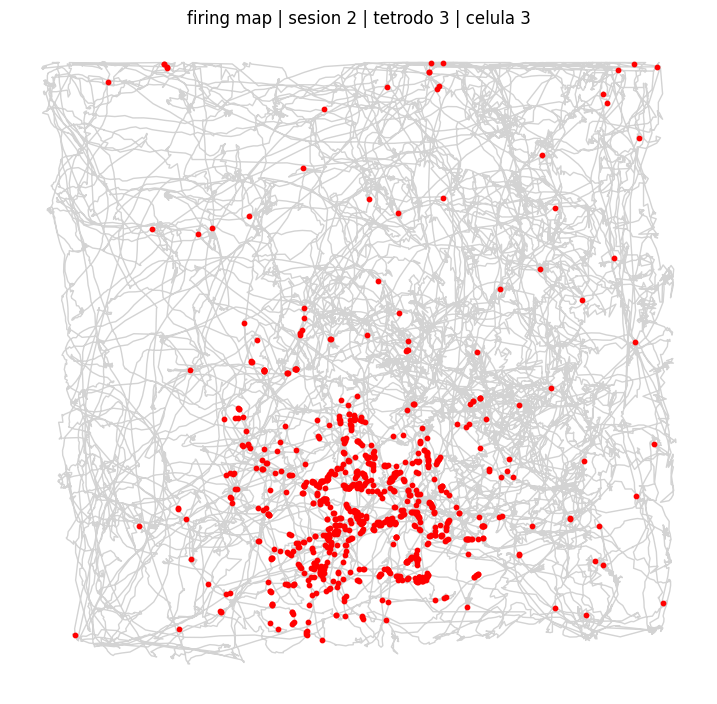

In [2]:
sesion, tetrodo, neurona = 2, 3, 3
bin_size = 0.1

firing_map(sesion, tetrodo, neurona)

## 2. GLM Posición


--- INICIANDO GLM ---
Construyendo Basis Functions (Grilla de 25x25 Campanas Gauss)...
Modelo entrenado


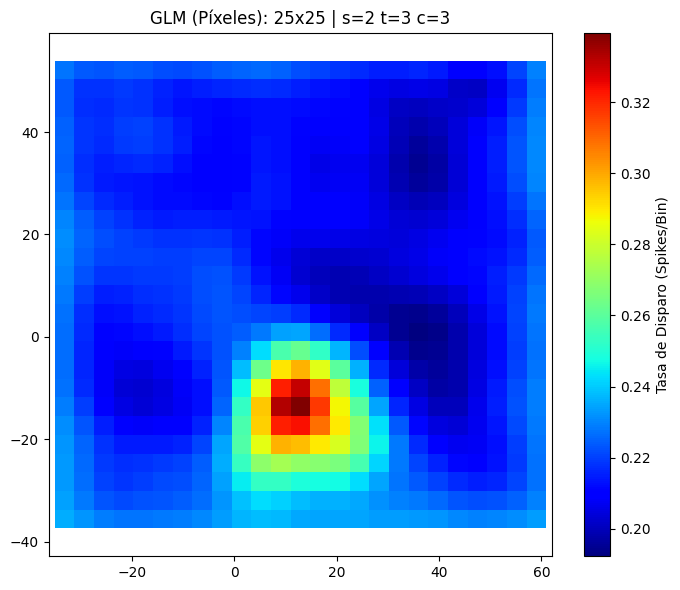

In [4]:
glm_posicion_manual(sesion, tetrodo, neurona, 25)

## 3. GAM Espacial (Place Cells)
Modela la respuesta de la neurona puramente a la posición (X, Y) usando splines.

[+] Cargando GAM Posición guardado desde modelo_gam_pos_s2_t3_n3_sp5.pkl...

=== RESUMEN GAM POSICIÓN ===
PoissonGAM                                                                                                
=============================================== ==========================================================
Distribution:                       PoissonDist Effective DoF:                                     14.2965
Link Function:                          LogLink Log Likelihood:                                 -2408.4966
Number of Samples:                        11952 AIC:                                             4845.5862
                                                AICc:                                             4845.628
                                                UBRE:                                               2.3144
                                                Scale:                                                 1.0
                                      

c:\Users\tomas\OneDrive\Escritorio\Octodon-Degus\scripts\utils\modeling.py:113: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  modelo_gam.summary()


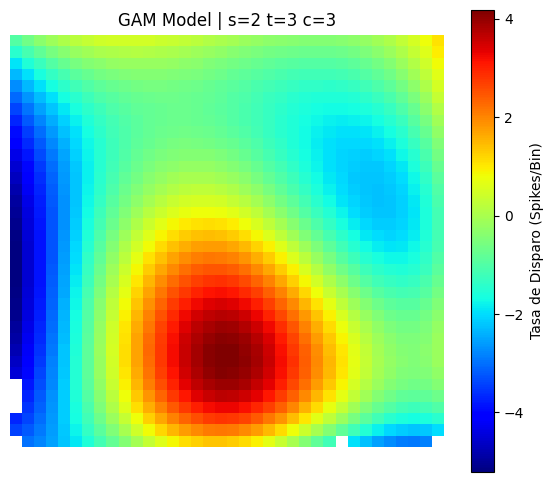

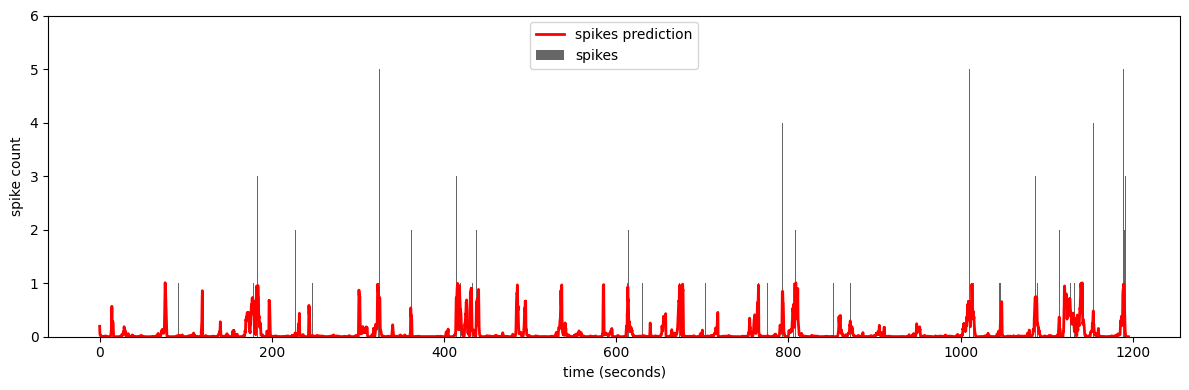

In [ ]:
## Cross-Validado manual: 5 splines y lambda 0.001 maximizan el NLL evaluando en test
## Los datos fueron separados en 20 chunks de ~1min consecutivos para evitar que datos
## del mismo evento vayan algunos a test o otros a train y el modelo memorice.

# -> modifiqué la función para ya no haga el .gridsearch() automático. calcula el lambda
#    óptimo usando una función que penaliza la "fexibilidad" EDoF alta. Esto simula bien
#    un overfitting sin separar train y test. para este caso el lambda que obtiene es el
#    mismo que el que obtuvimos con el k-folding. 
# -> en gral, el gridsearch elige el lambda que logra el mejor equilibrio: 
#    predecir bien los spikes, pero usando la curva más suave y rígida posible.
#    - lo bueno que tiene es que es rapidísimo porque es una cuenta.
#    - lo malo: la ecuación del GCV se construyó bajo el supuesto de que cada observación
#               es un evento completamente independiente del anterior.
# -> como esta neurona es muy estable, gridsearch nos coincide con kfold. pero por ejemplo,
#    si en una session el degu explora mucho arriba en los 1ros 10 min, y mucho abajo en 
#    los 2dos 10min, el gridsearch no va a tener problema en generar el modelo directo,
#    pero nuestra crossvalidación nos va a mostrar el problema real de que no podemos predecir
#    tan facil la 2da mitad si entrenamos con la 1ra. el gridsearch va a overfittear.

sesion, tetrodo, neurona = 2, 3, 3
bin_size = 0.1

splines_pos = 5
lam = 0.001

# Obtenemos el modelo (lo entrena si es la primera vez o lo carga de caché)

modelo_pos, X_pos, Y_pos = get_gam_posicion(sesion, tetrodo, neurona, splines_pos, lam, bin_size)

#modelo_pos, X_pos, Y_pos = get_gam_posicion(sesion, tetrodo, neurona, splines_pos, bin_size)

# Graficamos los resultados
graficar_gam_posicion(modelo_pos, X_pos, Y_pos, sesion, tetrodo, neurona, splines_pos, bin_size_sec=bin_size)

## 4. GAM Viewpoint (Mirada / Paredes)
Desenrolla la caja y calcula la respuesta hacia la mirada del animal usando GAMs 1D.

In [1]:
splines_vp = 20

# Obtenemos el modelo (lo entrena si es la primera vez o lo carga de caché)
modelo_vp, X_vp, Y_vp, W, H = get_gam_viewpoint_1d(sesion, tetrodo, neurona, splines_vp, bin_size)

# Graficamos los resultados
graficar_gam_viewpoint_1d(modelo_vp, X_vp, Y_vp, W, H, sesion, tetrodo, neurona)

NameError: name 'get_gam_viewpoint_1d' is not defined